# Handwritten Digit Recognition - Training Notebook

Full ML lifecycle: data collection, EDA, preprocessing, augmentation, model training, evaluation, and export.

Dataset: MNIST - 70,000 real handwritten digit images collected from US Census Bureau employees and high school students. This is genuine handwritten data, not synthetic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 1. Data Collection

In [2]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

print(f"Train samples: {x_train_raw.shape[0]}")
print(f"Test samples: {x_test_raw.shape[0]}")
print(f"Image shape: {x_train_raw.shape[1:]}")

Train samples: 60000
Test samples: 10000
Image shape: (28, 28)


## 2. Exploratory Data Analysis

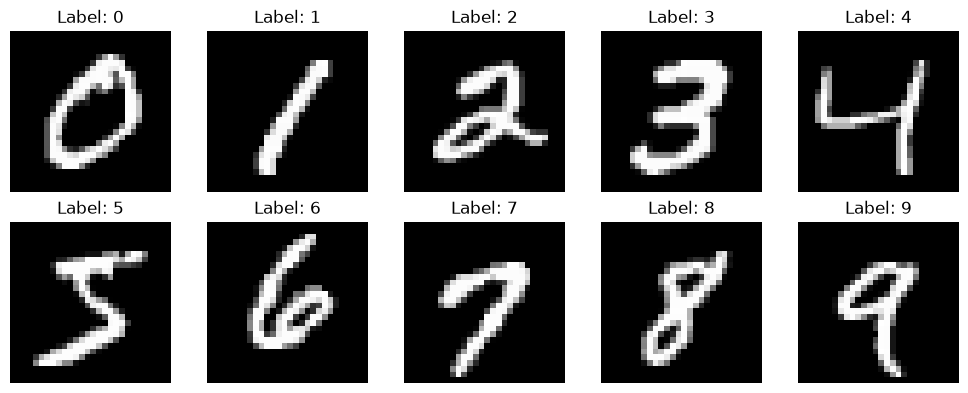

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_raw == i)[0][0]
    ax.imshow(x_train_raw[idx], cmap="gray")
    ax.set_title(f"Label: {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

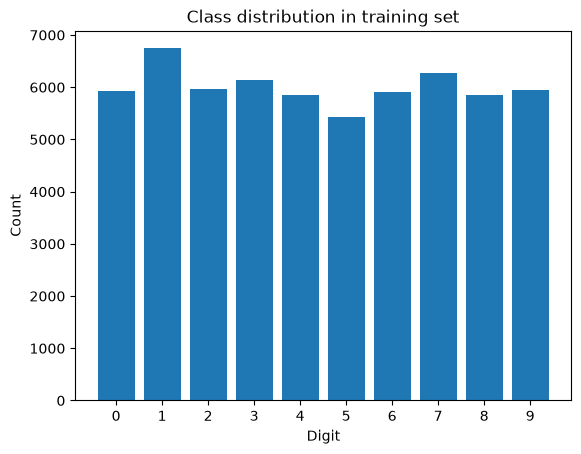

In [4]:
labels, counts = np.unique(y_train_raw, return_counts=True)
plt.bar(labels, counts)
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class distribution in training set")
plt.xticks(labels)
plt.show()

## 3. Preprocessing

In [5]:
x_train = np.expand_dims(x_train_raw.astype("float32") / 255.0, -1)
x_test = np.expand_dims(x_test_raw.astype("float32") / 255.0, -1)

y_train = keras.utils.to_categorical(y_train_raw, 10)
y_test = keras.utils.to_categorical(y_test_raw, 10)

split = int(0.9 * len(x_train))
x_train, x_val = x_train[:split], x_train[split:]
y_train, y_val = y_train[:split], y_train[split:]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

Train: (54000, 28, 28, 1), Val: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


## 4. Data Augmentation

Canvas-drawn digits vary in stroke width, position, and rotation compared to clean MNIST scans. Augmenting the training data makes the model more robust to real user drawings.

In [6]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(x_train)

## 5. Model Architecture

In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Training

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2),
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    validation_data=(x_val, y_val),
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.8813 - loss: 0.3810 - val_accuracy: 0.9062 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9576 - loss: 0.1377 - val_accuracy: 0.9857 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9668 - loss: 0.1050 - val_accuracy: 0.9870 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9714 - loss: 0.0916 - val_accuracy: 0.9822 - val_loss: 0.0611 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.9745 - loss: 0.0825 - val_accuracy: 0.9897 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 79ms/step - accuracy: 0.9767 - loss: 0.0761 - val_accuracy: 0.9917 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.9789 - l

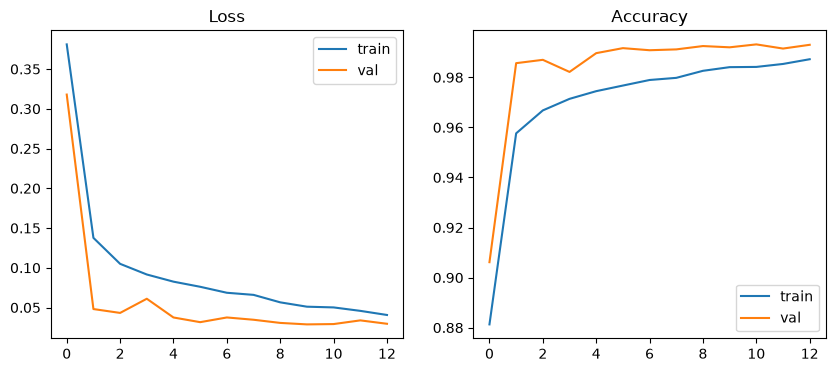

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.show()

## 7. Evaluation

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9933 - loss: 0.0213
Test accuracy: 0.9933


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


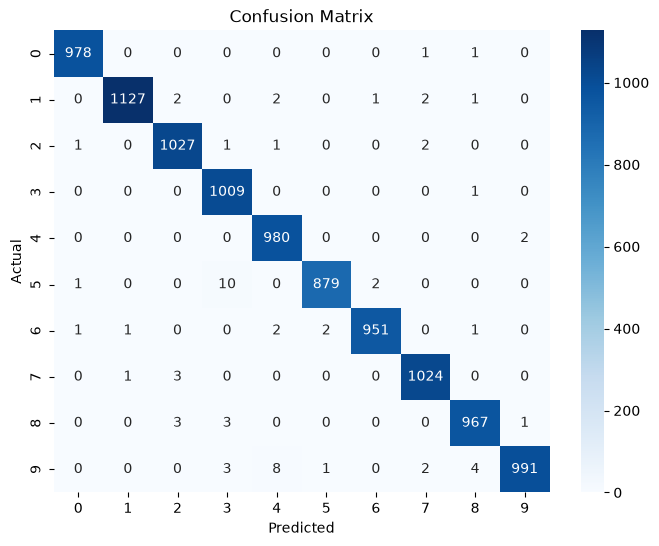

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [11]:
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

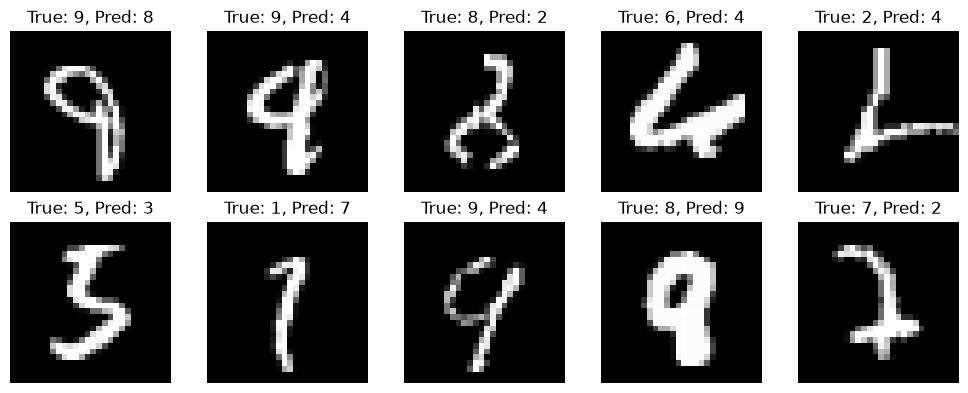

In [12]:
wrong_idx = np.where(y_pred != y_true)[0]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    if i >= len(wrong_idx):
        ax.axis("off")
        continue
    idx = wrong_idx[i]
    ax.imshow(x_test[idx].squeeze(), cmap="gray")
    ax.set_title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Save Model for Deployment

In [13]:
model.save("digit_model.keras")
print("Model saved as digit_model.keras")

Model saved as digit_model.keras
